# Hands-on 5 — Clustering and Markov state models

1. **K-means** on a two-dimensional toy model
2. **Clustering** the conformations of a real peptide
3. **Markov state model**: the kinetics between those conformations

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import MDAnalysis as mda
from sklearn.cluster import KMeans

rng = np.random.default_rng(42)

# Part 1 — K-means on a toy model

$N = 1500$ points $X_i$ in two dimensions, drawn from 5 Gaussian blobs.

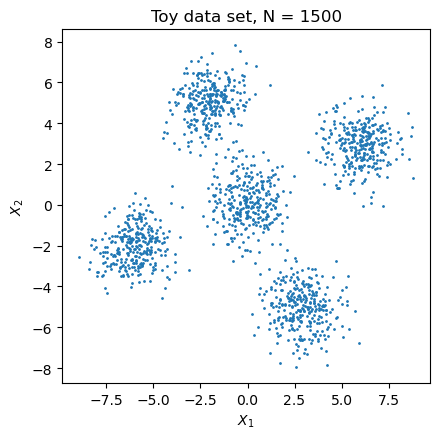

In [3]:
CENTRES = [(-6, -2), (-2, 5), (3, -5), (6, 3), (0, 0)]    # centres of the blobs
SIGMA = 1.0                                               # width of the blobs
NPOINTS = 300                                             # points per blob

blobs = []
for centre in CENTRES:
    blobs.append(rng.normal(loc=centre, scale=SIGMA, size=(NPOINTS, 2)))
X_toy = np.concatenate(blobs)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.plot(X_toy[:, 0], X_toy[:, 1], ".", ms=2)
ax.set(xlabel="$X_1$", ylabel="$X_2$", title=f"Toy data set, N = {len(X_toy)}")
plt.tight_layout()

### The algorithm

K-means minimises the objective

$$\mathcal L(\{z_i\}) = \sum_{l=1}^{k}\sum_{i=1}^{N} \delta_{z_i,l}\,\|X_i - C_l\|^2$$

1. initialise the $k$ centroids $\{C_l\}$ with $k$ data points chosen at random;
2. repeat until the memberships $\{z_i\}$ stop changing:
    1. assign each point to the closest centroid, $z_i = \arg\min_l d(X_i, C_l)$;
    2. update the centroids, $C_l = \sum_i \delta_{z_i,l} X_i \,/\, \sum_i \delta_{z_i,l}$.

> **Exercise:** Complete the function `k_means`.

In [ ]:
def k_means(X, k, rng, maxiter=100):
    """K-means with random initialisation.
    Returns the memberships z, the centroids C and the objective L."""
    N = len(X)

    # 1) initialise the k centroids with k data points chosen at random
    C = X[rng.choice(N, size=k, replace=False)].copy()
    z = np.zeros(N, dtype=int)

    for iteration in range(maxiter):
        # 2a) assign each point to the closest centroid
        d = np.zeros((N, k))
        for l in range(k):
            ...
        z_new = ...

        # stop when the memberships do not change anymore
        if iteration > 0 and np.all(z_new == z):
            break
        z = z_new

        # 2b) move each centroid to the mean of its members
        for l in range(k):
            members = X[z == l]
            if len(members) > 0:
                C[l] = ...

    L = np.sum(np.min(d, axis=1))                        # objective function
    return z, C, L

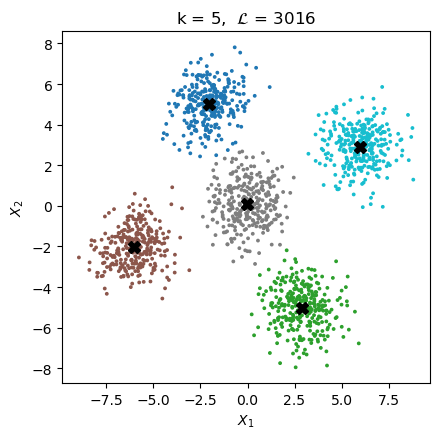

In [5]:
z, C, L = k_means(X=X_toy, k=5, rng=rng)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(X_toy[:, 0], X_toy[:, 1], c=z, cmap="tab10", s=3)
ax.plot(C[:, 0], C[:, 1], "kX", ms=8)
ax.set(xlabel="$X_1$", ylabel="$X_2$", title=f"k = 5,  $\\mathcal{{L}}$ = {L:.0f}")
plt.tight_layout()

### Sensitivity to the initialisation

K-means only finds a *local* minimum of $\mathcal L$. Let us repeat it 100 times, from 100 random
initialisations.

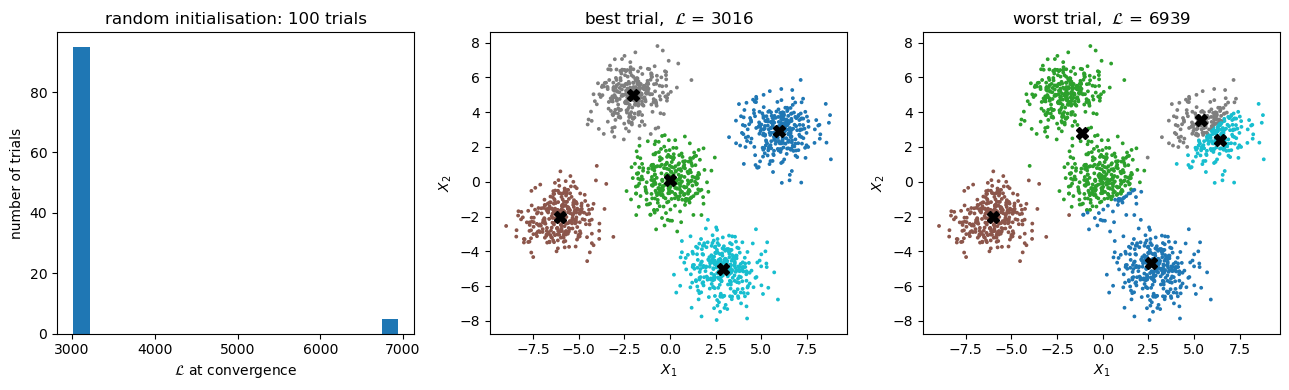

In [6]:
def plot_trials(X, results, title, L_range):
    """Histogram of the objective over the trials (in the interval L_range), and the best
    and worst partitions. results is a list of (z, C, L), one per trial."""
    L_trials = np.array([result[2] for result in results])
    best = results[np.argmin(L_trials)]
    worst = results[np.argmax(L_trials)]

    fig, ax = plt.subplots(1, 3, figsize=(13, 4))
    ax[0].hist(L_trials, bins=20, range=L_range)
    ax[0].set(xlabel="$\\mathcal{L}$ at convergence", ylabel="number of trials",
              title=f"{title}: {len(results)} trials")
    for a, (z, C, L), name in [(ax[1], best, "best"), (ax[2], worst, "worst")]:
        a.scatter(X[:, 0], X[:, 1], c=z, cmap="tab10", s=3)
        a.plot(C[:, 0], C[:, 1], "kX", ms=8)
        a.set(xlabel="$X_1$", ylabel="$X_2$", title=f"{name} trial,  $\\mathcal{{L}}$ = {L:.0f}")
    plt.tight_layout()


NTRIALS = 100
results = []
for trial in range(NTRIALS):
    results.append(k_means(X=X_toy, k=5, rng=rng))

L_range = (min(result[2] for result in results), max(result[2] for result in results))
plot_trials(X=X_toy, results=results, title="random initialisation", L_range=L_range)

### A smarter initialisation: k-means++

The `KMeans` of `sklearn` uses the k-means++ initialisation of the lecture. We run it 100 times, with a
single initialisation per run (`n_init=1`), and plot the same figures.

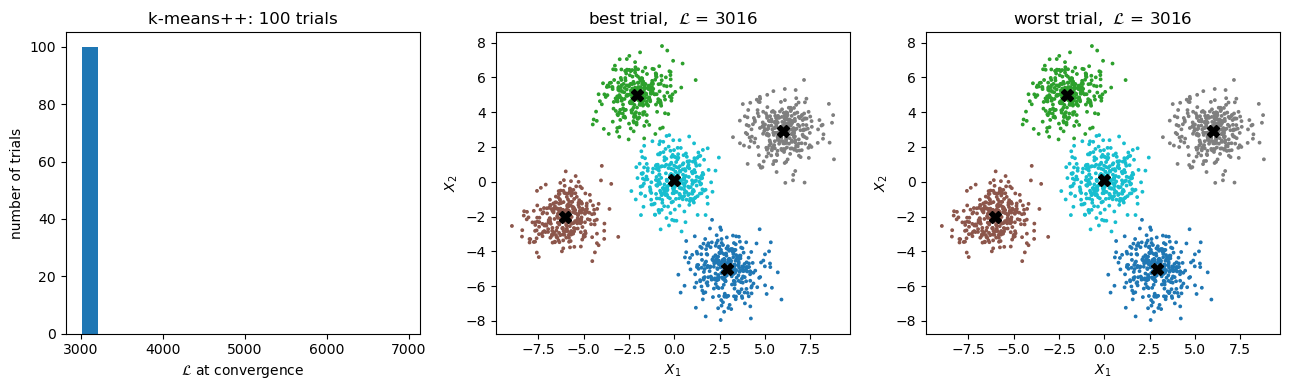

In [7]:
results_pp = []
for trial in range(NTRIALS):
    model = KMeans(n_clusters=5, init="k-means++", n_init=1, random_state=trial).fit(X_toy)
    results_pp.append((model.labels_, model.cluster_centers_, model.inertia_))

plot_trials(X=X_toy, results=results_pp, title="k-means++", L_range=L_range)   # same range as above

### How many clusters? The scree test

Plot the minimum of $\mathcal L$ as a function of $k$, and look for a knee. We use k-means++ with
10 initialisations (`n_init=10`), keeping the best one.

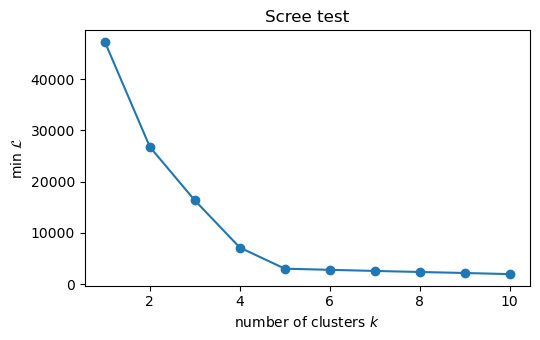

In [8]:
ks = np.arange(1, 11)
L_min = np.zeros(len(ks))
for j, k in enumerate(ks):
    L_min[j] = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=0).fit(X_toy).inertia_

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(ks, L_min, "o-")
ax.set(xlabel="number of clusters $k$", ylabel="min $\\mathcal{L}$", title="Scree test")
plt.tight_layout()

> **Exercise:** How does the knee change with the parameter `SIGMA`?

# Part 2 — The peptide

An **alanine hexamer** (Ac-Ala $_6$-NH $_2$, 42 atoms), simulated in vacuum for **20 ns at 500 K**.

In [9]:
DT = 10.0        # ps between consecutive frames
peptide = mda.Universe("trajectory.xyz", to_guess=["bonds", "angles", "dihedrals"], dt=DT)

# united-atom names (CH3, NH1, ...): we tell MDAnalysis the element of each atom (the first letter)
peptide.add_TopologyAttr("elements", [name[0] for name in peptide.atoms.names])
peptide.guess_TopologyAttrs(to_guess=["masses"], force_guess=["masses"])

nframes = len(peptide.trajectory)
print(f"{peptide.atoms.n_atoms} atoms, {nframes} frames, {nframes * DT / 1000:.0f} ns in total")

42 atoms, 2000 frames, 20 ns in total


In [10]:
# an interactive 3D view of the trajectory (skip this cell if nglview misbehaves)
import nglview as nv

view = nv.show_mdanalysis(peptide)
view

NGLWidget(max_frame=1999)

### Features

Our features $X_i$ are the backbone dihedrals $\phi$ and $\psi$ of the 6 residues (12 angles). We also
compute the radius of gyration $R_g$.

In [11]:
for i, d in enumerate(peptide.dihedrals):
    print(i, "-".join(d.atoms.names), list(d.atoms.indices))

0 CH3-C-NH1-H [np.int64(0), np.int64(1), np.int64(3), np.int64(4)]
1 CH3-C-NH1-CH1 [np.int64(0), np.int64(1), np.int64(3), np.int64(5)]
2 C-NH1-CH1-CH3 [np.int64(1), np.int64(3), np.int64(5), np.int64(6)]
3 C-NH1-CH1-C [np.int64(1), np.int64(3), np.int64(5), np.int64(7)]
4 O-C-NH1-H [np.int64(2), np.int64(1), np.int64(3), np.int64(4)]
5 O-C-NH1-CH1 [np.int64(2), np.int64(1), np.int64(3), np.int64(5)]
6 NH1-CH1-C-O [np.int64(3), np.int64(5), np.int64(7), np.int64(8)]
7 NH1-CH1-C-NH1 [np.int64(3), np.int64(5), np.int64(7), np.int64(9)]
8 H-NH1-CH1-CH3 [np.int64(4), np.int64(3), np.int64(5), np.int64(6)]
9 H-NH1-CH1-C [np.int64(4), np.int64(3), np.int64(5), np.int64(7)]
10 CH1-C-NH1-H [np.int64(5), np.int64(7), np.int64(9), np.int64(10)]
11 CH1-C-NH1-CH1 [np.int64(5), np.int64(7), np.int64(9), np.int64(11)]
12 CH3-CH1-C-O [np.int64(6), np.int64(5), np.int64(7), np.int64(8)]
13 CH3-CH1-C-NH1 [np.int64(6), np.int64(5), np.int64(7), np.int64(9)]
14 C-NH1-CH1-CH3 [np.int64(7), np.int64(9), np

In [12]:
# indices (in peptide.dihedrals) of the backbone angles of residues 1, ..., 6
PHI = [3, 15, 27, 39, 51, 63]      # C(r-1) - N(r) - CA(r) - C(r)
PSI = [7, 19, 31, 43, 55, 67]      # N(r) - CA(r) - C(r) - N(r+1)

phi = np.zeros((nframes, 6))       # phi[:, r] is the phi of residue r + 1, in degrees
psi = np.zeros((nframes, 6))       # psi[:, r] is the psi of residue r + 1, in degrees
rgyr = np.zeros(nframes)

for ts in peptide.trajectory:
    rgyr[ts.frame] = peptide.atoms.radius_of_gyration()
    for r in range(6):
        phi[ts.frame, r] = peptide.dihedrals[PHI[r]].value()
        psi[ts.frame, r] = peptide.dihedrals[PSI[r]].value()

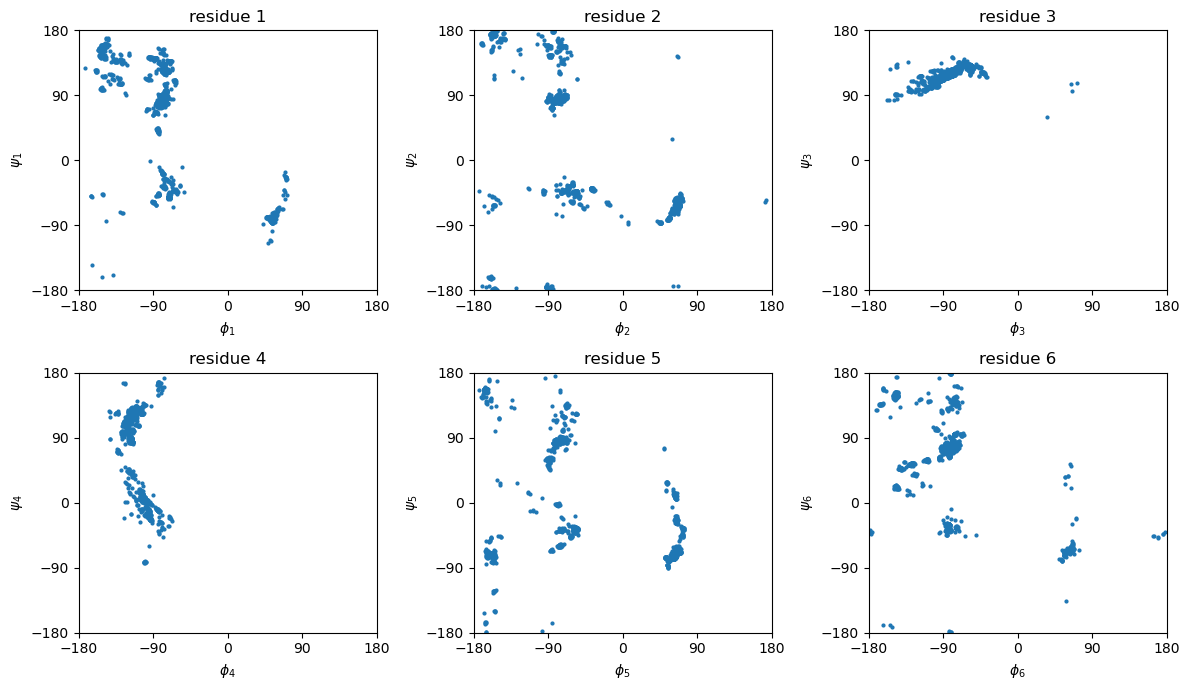

In [13]:
def ramachandran_grid(phi, psi, colors=None, cmap="tab10"):
    """One (phi, psi) plane per residue, optionally coloured by a label."""
    fig, ax = plt.subplots(2, 3, figsize=(12, 7))
    for r in range(6):
        a = ax.flat[r]
        if colors is None:
            a.scatter(phi[:, r], psi[:, r], s=4)
        else:
            a.scatter(phi[:, r], psi[:, r], c=colors, cmap=cmap, s=4)
        a.set(xlim=(-180, 180), ylim=(-180, 180),
              xticks=[-180, -90, 0, 90, 180], yticks=[-180, -90, 0, 90, 180],
              xlabel=f"$\\phi_{r + 1}$", ylabel=f"$\\psi_{r + 1}$", title=f"residue {r + 1}")
    plt.tight_layout()


ramachandran_grid(phi=phi, psi=psi)

The quenched structures sit in a few well-separated blobs. Residues 3 and 4 stay in a single blob,
while residues 1, 2, 5, 6 visit several of them. This suggests that the molecule is rotationally "rigid" inside, and has more roational freedom when we get close to the termini.

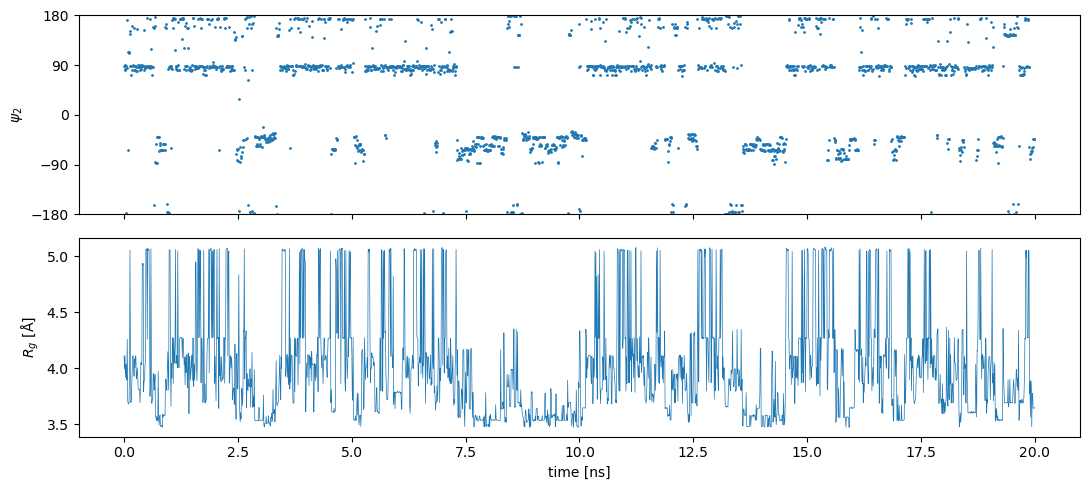

In [14]:
time = np.arange(nframes) * DT / 1000.0          # in ns

fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ax[0].plot(time, psi[:, 1], ".", ms=2)                   # residue 2
ax[0].set(ylabel="$\\psi_2$", ylim=(-180, 180), yticks=[-180, -90, 0, 90, 180])
ax[1].plot(time, rgyr, lw=0.5)
ax[1].set(xlabel="time [ns]", ylabel="$R_g$ [Å]")
plt.tight_layout()

$\psi_2$ jumps between a few values and stays in each of them for a while: **metastability**.

> **Exercise:** Plot the same time series for $\phi_3$ and $\phi_5$. Which angles look metastable?

## Clustering the peptide

As in Part 1, we use the `KMeans` of `sklearn` (k-means++, `n_init` initialisations).

In [15]:
def circular_features(angles_deg):
    """(cos, sin) of each angle: shape (nframes, nangles) -> (nframes, 2 * nangles)."""
    radians = np.deg2rad(angles_deg)
    return np.hstack([np.cos(radians), np.sin(radians)])

X = circular_features(angles_deg=np.hstack([phi, psi]))   # the 12 angles, (cos, sin) of each
X = np.column_stack([X, rgyr])
print("feature matrix:", X.shape)

feature matrix: (2000, 25)


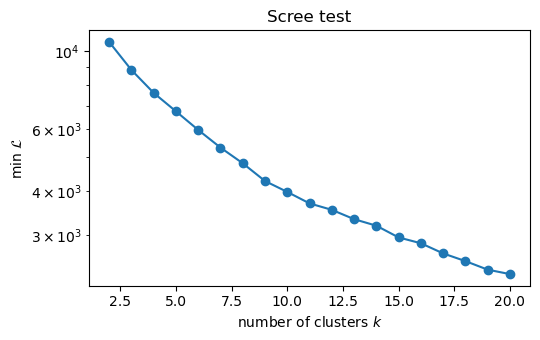

In [16]:
ks = np.arange(2, 21)
L_min = np.zeros(len(ks))
for j, k in enumerate(ks):
    L_min[j] = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X).inertia_

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(ks, L_min, "o-")
ax.set(xlabel="number of clusters $k$", ylabel="min $\\mathcal{L}$", title="Scree test", yscale="log")
plt.tight_layout()

Unlike the toy model, there is no knee: the conformational space is not made of $k$ round,
well-separated blobs. Let us look at $k = 4$ anyway.

cluster 0:  30.8 %   F =  0.0 kJ/mol   <Rg> = 3.64 Å
cluster 1:  28.1 %   F =  0.4 kJ/mol   <Rg> = 3.93 Å
cluster 2:  29.3 %   F =  0.2 kJ/mol   <Rg> = 4.37 Å
cluster 3:  11.8 %   F =  4.0 kJ/mol   <Rg> = 4.22 Å


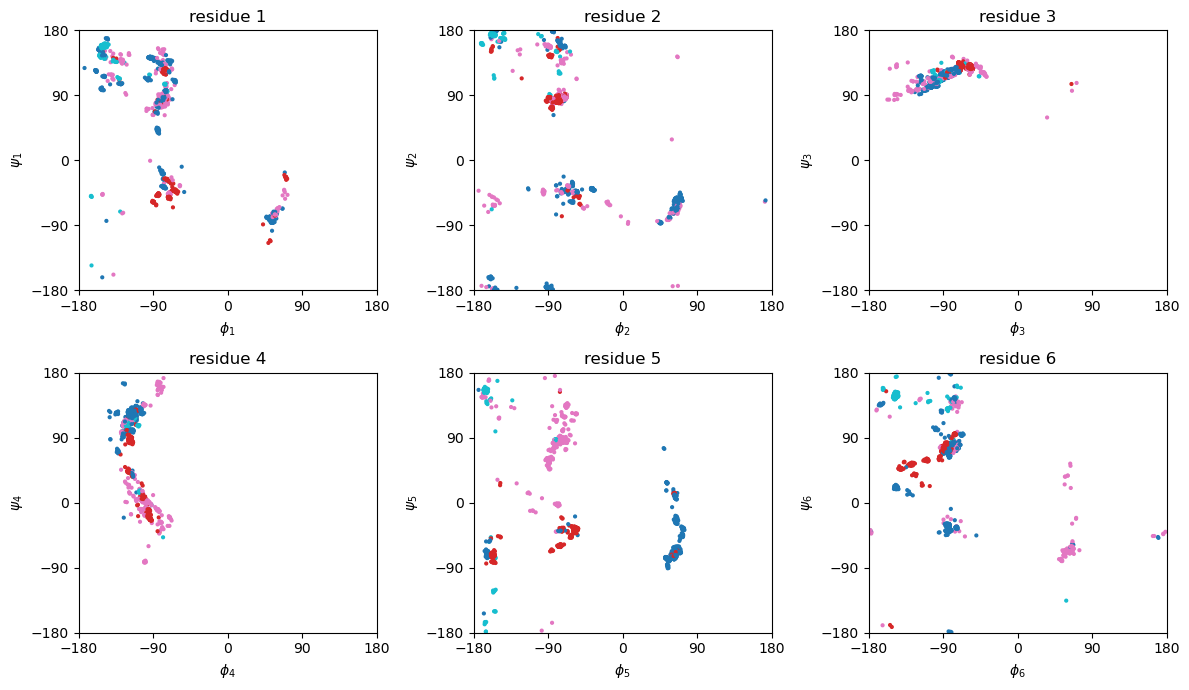

In [17]:
NCLUSTERS = 4
cluster = KMeans(n_clusters=NCLUSTERS, n_init=20, random_state=0).fit(X).labels_

# population and free energy of each cluster:  F_l = -kT log(N_l / N)
KT = 0.0083145 * 500.0                     # kJ/mol at 500 K
population = np.bincount(cluster) / nframes
free_energy = -KT * np.log(population)
free_energy = free_energy - free_energy.min()

for l in range(NCLUSTERS):
    print(f"cluster {l}: {population[l] * 100:5.1f} %   "
          f"F = {free_energy[l]:4.1f} kJ/mol   <Rg> = {rgyr[cluster == l].mean():.2f} Å")

ramachandran_grid(phi=phi, psi=psi, colors=cluster)

In [18]:
from MDAnalysis.analysis import align

SHOW = 0                                   # which cluster to look at
filename = f"cluster_{SHOW}.xyz"
peptide.atoms.write(filename, frames=peptide.trajectory[cluster == SHOW])

u_cluster = mda.Universe(filename, to_guess=["bonds", "angles", "dihedrals", "masses"], dt=DT)
reference = mda.Universe(filename, to_guess=["bonds", "angles", "dihedrals", "masses"], dt=DT)
align.AlignTraj(u_cluster, reference, select="all", in_memory=True).run()   # remove rototranslations

view = nv.show_mdanalysis(u_cluster)
view

NGLWidget(max_frame=614)

In [19]:
view._iplayer

> **Exercise:** Can you find "better" clusters using other variables?

The clustering never looked at the order of the frames: it tells us nothing about the kinetics.

# Part 3 — Markov state model

### Microstates and transition matrix

We partition the space into many small clusters, the **microstates** $\alpha = 1,\dots,K$, and look at
the trajectory every $\tau$. If the jumps between microstates are Markovian,

$$P(t+\tau) = P(t)\,\Pi, \qquad $$

As a first step, let's run KMeans++ (using the SKLearn implementation) on our data, using the dihedrals.

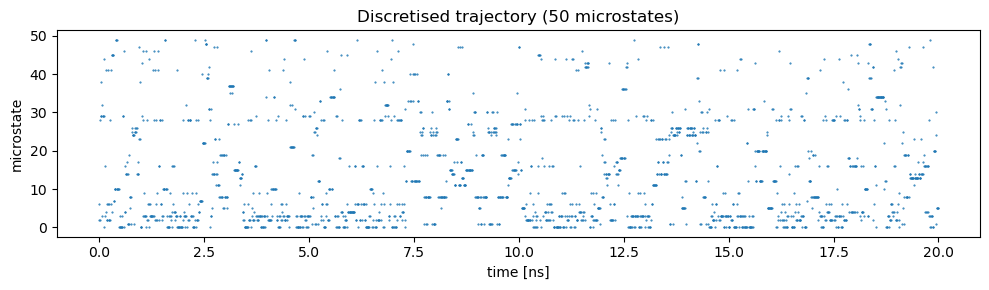

In [20]:
K = 50                                     # number of microstates
micro_model = KMeans(n_clusters=K, n_init=20, random_state=0).fit(X)
micro = micro_model.labels_                # microstate of each frame

# discretised trajectory: the microstate visited at each frame
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(np.arange(len(micro)) * DT / 1000, micro, ".", ms=1)
ax.set(xlabel="time [ns]", ylabel="microstate", title=f"Discretised trajectory ({K} microstates)")
plt.tight_layout()

We now compute the transition matrix, which can be computed as 

$$ \Pi_{\alpha\beta} \simeq \frac{C_{\alpha\beta}}{\sum_\beta C_{\alpha\beta}} $$

where $C_{\alpha\beta}$ counts the times the trajectory is in $\alpha$ at $t$ and in $\beta$ at $t+\tau$. We symmetrise the counts, $C \to C + C^{\mathsf T}$: this imposes detailed balance,
$P_{{\rm eq},\alpha}\Pi_{\alpha\beta} = P_{{\rm eq},\beta}\Pi_{\beta\alpha}$, as for an equilibrium
trajectory.

> **Exercise**: Complete the function `transition matrix` below.

In [ ]:
def transition_matrix(state_series, nstates, lag):
    """Row-stochastic transition matrix Pi[alpha, beta] at lag time `lag`.

    Args:
        state_series: 1D array with the state label of each frame (int numbers from 0 to K-1)
        nstates: number of states / clusters, K
        lag: lag time tau, in frames, at which the transitions are counted

    Returns:
        Pi: (K, K) transition matrix, each row sums to 1
    """
    # 1) count matrix
    C = np.zeros((nstates, nstates))            # transition counts
    for t in range(len(state_series) - lag):
        ...            # state at t
        ...            # state at t + lag
        ...

    # 2) symmetrise the counts
    Csym = C + C.T                              # detailed balance

    # 3) normalise each row
    Pi = ... # row-stochastic
    return Pi


def spectrum(Pi):
    """Eigenvalues (sorted by decreasing modulus) and left eigenvectors u_j of Pi.
    u[:, j] is the j-th left eigenvector: u_j^T Pi = lambda_j u_j^T."""
    eigenvalues, u = np.linalg.eig(Pi.T)
    order = np.argsort(-np.abs(eigenvalues))
    return np.real(eigenvalues[order]), np.real(u[:, order])

In [22]:
K = 50                                     # number of microstates
micro_model = KMeans(n_clusters=K, n_init=20, random_state=0).fit(X)
micro = micro_model.labels_                # microstate of each frame

In [23]:
LAG = 4                                    # tau, in frames: 40 ps
Pi = transition_matrix(state_series=micro, nstates=K, lag=LAG)

# stationary distribution: the left eigenvector u_0 of Pi (eigenvalue 1), normalised to 1
eigenvalues, u = spectrum(Pi=Pi)
P_eq = u[:, 0] / u[:, 0].sum()

print(f"rows of Pi sum to 1          : {np.allclose(Pi.sum(axis=1), 1.0)}")
print(f"P_eq Pi = P_eq               : {np.allclose(P_eq @ Pi, P_eq)}")

rows of Pi sum to 1          : True
P_eq Pi = P_eq               : True


### The spectrum

With $u_j^{\mathsf T}\Pi = \lambda_j u_j^{\mathsf T}$, $\;1 = \lambda_0 > |\lambda_1| \ge |\lambda_2| \ge \dots$
and $u_0 = P_{\rm eq}$, each eigenvalue defines a relaxation time

$$\tau_j = -\frac{\tau}{\log|\lambda_j|}$$

In [24]:
def implied_timescales(eigenvalues, lag):
    """tau_j = -tau / log|lambda_j| for j >= 1, in ps."""
    return -lag * DT / np.log(np.abs(eigenvalues[1:]))

tau_1 = 378 ps,  tau_2 = 177 ps,  tau_3 = 103 ps


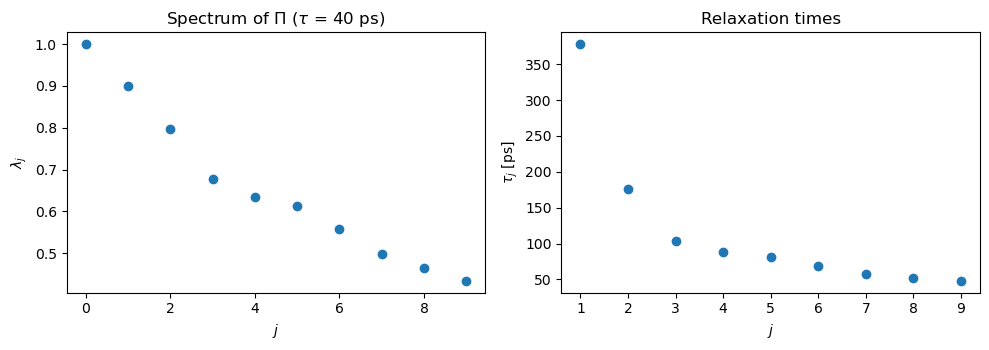

In [25]:
eigenvalues, u = spectrum(Pi=Pi)
timescales = implied_timescales(eigenvalues=eigenvalues, lag=LAG)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(np.arange(10), eigenvalues[:10], "o")
ax[0].set(xlabel="$j$", ylabel="$\\lambda_j$", title=f"Spectrum of $\\Pi$ ($\\tau$ = {LAG * DT:.0f} ps)")
ax[1].plot(np.arange(1, 10), timescales[:9], "o")
ax[1].set(xlabel="$j$", ylabel="$\\tau_j$ [ps]", title="Relaxation times")
plt.tight_layout()

print(f"tau_1 = {timescales[0]:.0f} ps,  tau_2 = {timescales[1]:.0f} ps,  tau_3 = {timescales[2]:.0f} ps")

There is a gap after $\lambda_1$: one slow process, $\tau_1 \simeq 350$ ps, about twice as slow as the next.

### Is the dynamics Markovian?

The relaxation times are a property of the system, so they must not depend on the lag $\tau$.

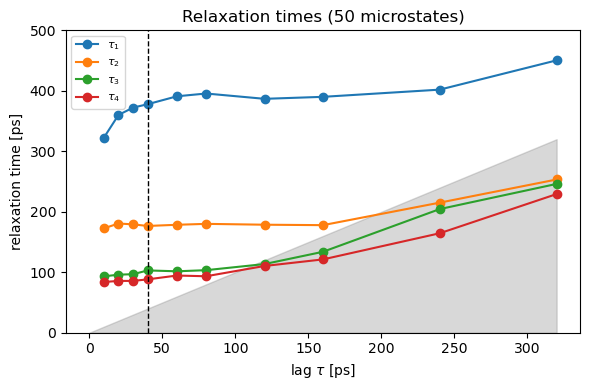

In [26]:
lags = np.array([1, 2, 3, 4, 6, 8, 12, 16, 24, 32])
its = np.zeros((len(lags), 4))
for i, lag in enumerate(lags):
    Pi_lag = transition_matrix(state_series=micro, nstates=K, lag=lag)
    values, vectors = spectrum(Pi=Pi_lag)
    its[i] = implied_timescales(eigenvalues=values, lag=lag)[:4]

fig, ax = plt.subplots(figsize=(6, 4))
for j in range(4):
    ax.plot(lags * DT, its[:, j], "o-", label=f"$\\tau_{j + 1}$")
ax.fill_between([0, lags[-1] * DT], [0, 0], [0, lags[-1] * DT], color="gray", alpha=0.3)   # tau_j < tau
ax.axvline(LAG * DT, color="k", ls="--", lw=1)
ax.set(xlabel="lag $\\tau$ [ps]", ylabel="relaxation time [ps]", ylim=(0, 500),
       title=f"Relaxation times ({K} microstates)")
ax.legend(fontsize=8)
plt.tight_layout()

The curves are flat: the model is Markovian already at the shortest lags. In the grey region
$\tau_j < \tau$ the relaxation times cannot be resolved.

> **Exercise:** Redo this plot with `K = 5`. Are the relaxation times still flat?

# Part 4 — Markov states

The signs of the components of $u_1$ define the two Markov states:

$$A := \{\alpha : u_{1,\alpha} > 0\}, \qquad B := \{\alpha : u_{1,\alpha} < 0\}$$

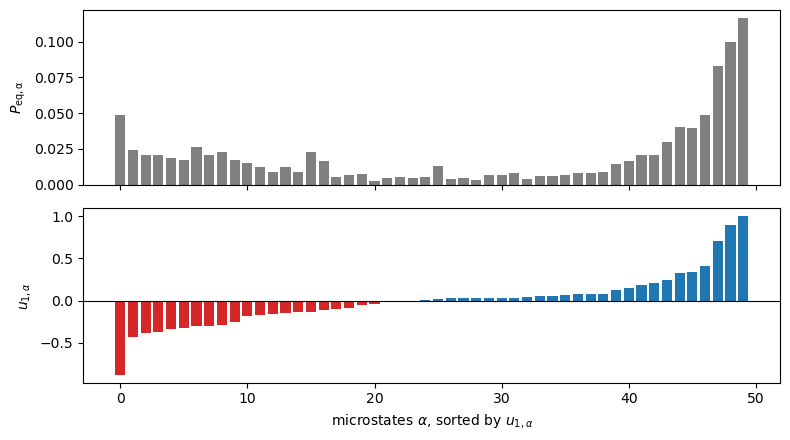

In [27]:
u1 = u[:, 1]
u1 = u1 / np.abs(u1).max()
order = np.argsort(u1)                     # microstates sorted by u_1

fig, ax = plt.subplots(2, 1, figsize=(8, 4.5), sharex=True)
ax[0].bar(np.arange(K), P_eq[order], color="gray")
ax[0].set(ylabel="$P_{\\rm eq,\\alpha}$")
ax[1].bar(np.arange(K), u1[order], color=np.where(u1[order] > 0, "C0", "C3"))
ax[1].axhline(0.0, color="k", lw=0.8)
ax[1].set(xlabel="microstates $\\alpha$, sorted by $u_{1,\\alpha}$", ylabel="$u_{1,\\alpha}$")
plt.tight_layout()

In [28]:
macro_of_micro = (u1 > 0).astype(int)      # 1 = A, 0 = B
macro = macro_of_micro[micro]              # Markov state of every frame

population = np.bincount(macro) / nframes
free_energy = -KT * np.log(population)
free_energy = free_energy - free_energy.min()

for m, name in [(1, "A"), (0, "B")]:
    print(f"state {name}: {np.sum(macro_of_micro == m):2d} microstates, "
          f"{population[m] * 100:4.1f} % of the frames, F = {free_energy[m]:4.1f} kJ/mol")
print(f"{np.sum(macro[1:] != macro[:-1])} transitions between A and B")

state A: 26 microstates, 63.0 % of the frames, F =  0.0 kJ/mol
state B: 24 microstates, 37.0 % of the frames, F =  2.2 kJ/mol
49 transitions between A and B


### What is the slow process?

We compare the two states angle by angle, averaging on the circle, $\bar\theta = \arg\langle e^{i\theta}\rangle$.

In [29]:
def circular_mean(angles_deg):
    """Mean of a set of angles (in degrees), computed on the circle."""
    radians = np.deg2rad(angles_deg)
    return np.rad2deg(np.arctan2(np.sin(radians).mean(), np.cos(radians).mean()))


print("            A       B   difference")
for name, angle in [("phi", phi), ("psi", psi)]:
    for r in range(6):
        mean_A = circular_mean(angles_deg=angle[macro == 1, r])
        mean_B = circular_mean(angles_deg=angle[macro == 0, r])
        difference = abs(mean_A - mean_B)
        difference = min(difference, 360.0 - difference)
        flag = "  <---" if difference > 60.0 else ""
        print(f"  {name}_{r + 1}  {mean_A:6.0f}  {mean_B:6.0f}  {difference:7.0f}{flag}")

print(f"\n<Rg> = {rgyr[macro == 1].mean():.2f} Å (A)  and  {rgyr[macro == 0].mean():.2f} Å (B)")

            A       B   difference
  phi_1     -88     -84        4
  phi_2     -90      -5       85  <---
  phi_3     -76     -94       18
  phi_4    -112    -114        2
  phi_5    -105      57      162  <---
  phi_6     -97     -84       13
  psi_1     107     101        6
  psi_2     101     -69      170  <---
  psi_3     122     113        9
  psi_4      71     117       45
  psi_5      31     -50       82  <---
  psi_6      82      36       46

<Rg> = 4.20 Å (A)  and  3.68 Å (B)


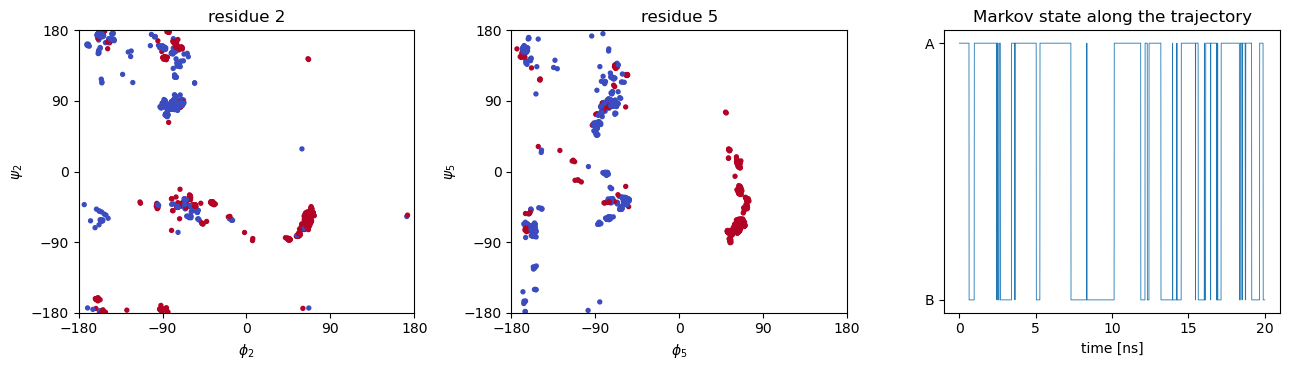

In [30]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
for a, residue in [(ax[0], 2), (ax[1], 5)]:
    r = residue - 1                                     # column of this residue in phi and psi
    a.scatter(phi[:, r], psi[:, r], c=macro, cmap="coolwarm_r", s=8)
    a.set(xlim=(-180, 180), ylim=(-180, 180),
          xticks=[-180, -90, 0, 90, 180], yticks=[-180, -90, 0, 90, 180],
          xlabel=f"$\\phi_{residue}$", ylabel=f"$\\psi_{residue}$", title=f"residue {residue}")

ax[2].plot(time, macro, lw=0.6)
ax[2].set(xlabel="time [ns]", yticks=[0, 1], yticklabels=["B", "A"], title="Markov state along the trajectory")
plt.tight_layout()

The slow process is a concerted flip of residues 2 and 5, at the two ends of the chain, while the core
(residues 3 and 4) stays in the same basin.

In [31]:
STATE = "A"                                # which Markov state to look at: "A" or "B"
if STATE == "A":
    selected = macro == 1
else:
    selected = macro == 0

filename = f"markov_state_{STATE}.xyz"
peptide.atoms.write(filename, frames=peptide.trajectory[selected])

u_state = mda.Universe(filename, to_guess=["bonds", "angles", "dihedrals", "masses"], dt=DT)
reference = mda.Universe(filename, to_guess=["bonds", "angles", "dihedrals", "masses"], dt=DT)
align.AlignTraj(u_state, reference, select="all", in_memory=True).run()   # remove rototranslations

view = nv.show_mdanalysis(u_state)
view

NGLWidget(max_frame=1259)

In [32]:
view._iplayer

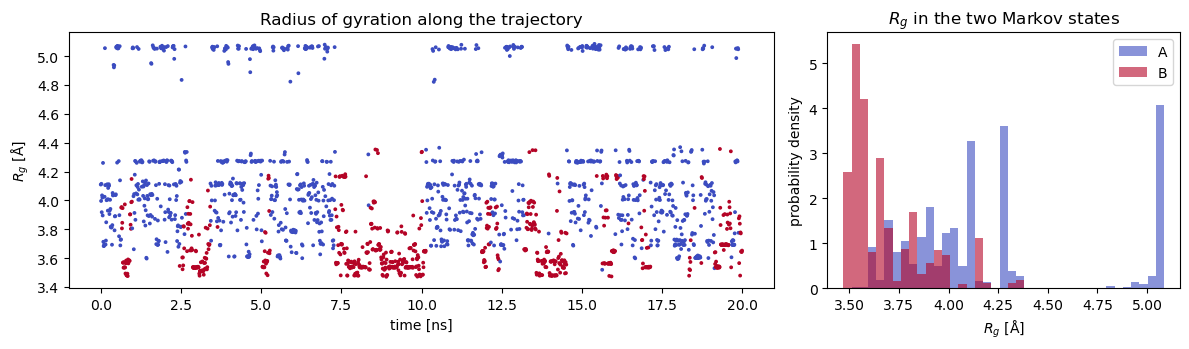

In [33]:
color_A = plt.cm.coolwarm_r(1.0)          # same colours as the Ramachandran planes above
color_B = plt.cm.coolwarm_r(0.0)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6), width_ratios=[2, 1])
ax[0].scatter(time, rgyr, c=macro, cmap="coolwarm_r", s=3)
ax[0].set(xlabel="time [ns]", ylabel="$R_g$ [Å]", title="Radius of gyration along the trajectory")

bins = np.linspace(rgyr.min(), rgyr.max(), 40)
ax[1].hist(rgyr[macro == 1], bins=bins, density=True, alpha=0.6, color=color_A, label="A")
ax[1].hist(rgyr[macro == 0], bins=bins, density=True, alpha=0.6, color=color_B, label="B")
ax[1].set(xlabel="$R_g$ [Å]", ylabel="probability density", title="$R_g$ in the two Markov states")
ax[1].legend()
plt.tight_layout()

> **Exercise:** Look at the conformations of state B (`STATE = "B"`). Which residues are left-handed ($\phi > 0$)? Is B more or less compact than A?

### Rates

For two states the relaxation rate is the sum of the two rates, and detailed balance fixes their ratio:

$$\frac{1}{\tau_1} = k_{A\to B} + k_{B\to A}, \qquad P_A\,k_{A\to B} = P_B\,k_{B\to A}
\quad\Longrightarrow\quad k_{A\to B} = \frac{P_B}{\tau_1}$$

The mean first passage time is $1/k_{A\to B}$.

In [34]:
P_A = population[1]
P_B = population[0]
tau_1 = timescales[0]

print(f"mean first passage time A -> B = {tau_1 / P_B:5.0f} ps")
print(f"mean first passage time B -> A = {tau_1 / P_A:5.0f} ps")

mean first passage time A -> B =  1021 ps
mean first passage time B -> A =   600 ps


### Why many microstates?

Let us build the same model directly on the two Markov states, and compare its $\tau_1$ with the one of
the 50 microstates.

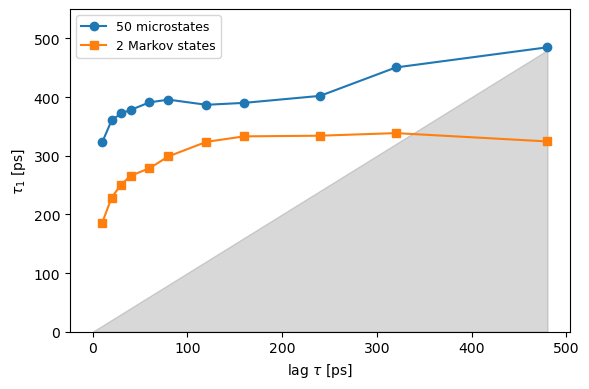

In [35]:
lags = np.array([1, 2, 3, 4, 6, 8, 12, 16, 24, 32, 48])
tau1_micro = np.zeros(len(lags))
tau1_macro = np.zeros(len(lags))
for i, lag in enumerate(lags):
    values, vectors = spectrum(Pi=transition_matrix(state_series=micro, nstates=K, lag=lag))
    tau1_micro[i] = implied_timescales(eigenvalues=values, lag=lag)[0]
    values, vectors = spectrum(Pi=transition_matrix(state_series=macro, nstates=2, lag=lag))
    tau1_macro[i] = implied_timescales(eigenvalues=values, lag=lag)[0]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(lags * DT, tau1_micro, "o-", label=f"{K} microstates")
ax.plot(lags * DT, tau1_macro, "s-", label="2 Markov states")
ax.fill_between([0, lags[-1] * DT], [0, 0], [0, lags[-1] * DT], color="gray", alpha=0.3)
ax.set(xlabel="lag $\\tau$ [ps]", ylabel="$\\tau_1$ [ps]", ylim=(0, 550))
ax.legend(fontsize=9)
plt.tight_layout()

With only two states, $\tau_1$ is strongly underestimated at short lags. A large state is not
"memoryless": close to the boundary between A and B, the trajectory crosses back and forth many times,
and each recrossing is counted as a transition. Small microstates avoid this, because the recrossings
happen *inside* a single microstate.